# 1、数据预处理

In [33]:
import os
import numpy as np
import scipy.io as sio
from tqdm import tqdm
from pyts.image import GramianAngularField
from skimage.transform import resize

In [45]:
# 数据路径
DE_PATH = "./驱动端"
FE_PATH = "./风扇端"

# 输出路径 (建议改个名字区分)
SAVE_PATH = "./CWRU_GAF128"

# 滑窗参数
WINDOW_SIZE = 1024
OVERLAP = 512
STEP = WINDOW_SIZE - OVERLAP

# GAF 尺寸改为 128
IMAGE_SIZE = 128

In [46]:
fault_dict = {

# -------------------
# 驱动端
# -------------------

"106":"IR_007",
"170":"IR_014",
"210":"IR_021",

"119":"B_007",
"186":"B_014",
"223":"B_021",

"131":"OR_007",
"198":"OR_014",
"235":"OR_021",

"98":"Normal",


# -------------------
# 风扇端
# -------------------

"279":"IR_007",
"275":"IR_014",
"271":"IR_021",

"283":"B_007",
"287":"B_014",
"291":"B_021",

"299":"OR_007",
"309":"OR_014",
"316":"OR_021",

}

In [47]:
def load_signal(file_path, channel):

    mat = sio.loadmat(file_path)

    for key in mat.keys():

        if channel == "DE" and "DE_time" in key:
            return mat[key].flatten()

        if channel == "FE" and "FE_time" in key:
            return mat[key].flatten()

    return None

In [48]:
def sliding_window(signal):

    segments = []

    for start in range(0, len(signal) - WINDOW_SIZE, STEP):

        seg = signal[start:start + WINDOW_SIZE]

        segments.append(seg)

    return np.array(segments)

In [49]:
gaf = GramianAngularField(method='summation')

def signal_to_gaf(signal):

    signal = signal.reshape(1, -1)

    img = gaf.fit_transform(signal)

    return img[0]

In [50]:
import cv2
import numpy as np

def resize_img(img):
    # 使用 OpenCV 的 INTER_AREA 算法进行高质量的高频特征保留压缩
    img_resized = cv2.resize(img, (IMAGE_SIZE, IMAGE_SIZE), interpolation=cv2.INTER_AREA)
    return img_resized

In [51]:
def process_file(file_path, channel):

    file_name = os.path.basename(file_path)

    number = file_name.replace(".mat","")

    if number not in fault_dict:
        return

    label = fault_dict[number]

    signal = load_signal(file_path, channel)

    if signal is None:
        return

    segments = sliding_window(signal)

    save_dir = os.path.join(SAVE_PATH, channel, label)

    os.makedirs(save_dir, exist_ok=True)

    for i, seg in enumerate(segments):

        gaf_img = signal_to_gaf(seg)

        img = resize_img(gaf_img)

        np.save(
            os.path.join(save_dir,f"{number}_{i}.npy"),
            img
        )

In [52]:
def process_DE():

    files = os.listdir(DE_PATH)

    for f in tqdm(files):

        if f.endswith(".mat"):

            path = os.path.join(DE_PATH,f)

            process_file(path,"DE")

In [53]:
process_DE()

100%|██████████| 9/9 [00:23<00:00,  2.61s/it]


In [54]:
def process_FE():

    files = os.listdir(FE_PATH)

    for f in tqdm(files):

        if f.endswith(".mat"):

            path = os.path.join(FE_PATH,f)

            process_file(path,"FE")

In [55]:
process_FE()

100%|██████████| 9/9 [00:14<00:00,  1.62s/it]


# 2、模型构建

In [29]:
import os
import glob
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

# 定义 10 种故障状态的标签映射
LABEL_MAP = {
    "Normal": 0,
    "IR_007": 1, "IR_014": 2, "IR_021": 3,
    "B_007": 4,  "B_014": 5,  "B_021": 6,
    "OR_007": 7, "OR_014": 8, "OR_021": 9
}

class GAFDataset(Dataset):
    def __init__(self, file_paths, labels):
        self.file_paths = file_paths
        self.labels = labels

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        # 读取 64x64 的 GAF 图像
        img = np.load(self.file_paths[idx])
        # PyTorch 要求输入通道在前: (C, H, W)
        img = img.reshape(1, 128, 128).astype(np.float32)
        label = self.labels[idx]
        return torch.tensor(img), torch.tensor(label, dtype=torch.long)

def load_data(channel="DE", test_size=0.2, val_size=0.1):
    base_dir = f"./CWRU_GAF128/{channel}"
    all_files = []
    all_labels = []
    
    # 遍历所有类别文件夹
    for label_str, label_idx in LABEL_MAP.items():
        folder_path = os.path.join(base_dir, label_str)
        files = glob.glob(os.path.join(folder_path, "*.npy"))
        all_files.extend(files)
        all_labels.extend([label_idx] * len(files))
        
    # 划分训练集和临时测试集 (包含验证集)
    X_train, X_temp, y_train, y_temp = train_test_split(
        all_files, all_labels, test_size=(test_size + val_size), random_state=42, stratify=all_labels
    )
    # 划分验证集和最终测试集 (用于后续 D-S 融合)
    ratio = test_size / (test_size + val_size)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=ratio, random_state=42, stratify=y_temp
    )
    
    return (X_train, y_train), (X_val, y_val), (X_test, y_test)

In [30]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

class MorletConv2d(nn.Module):
    def __init__(self, out_channels, kernel_size):
        super(MorletConv2d, self).__init__()
        self.kernel_size = kernel_size
        self.out_channels = out_channels
        
        # 可学习参数：中心频率 f 和 尺度 sigma
        self.f = nn.Parameter(torch.rand(out_channels, 1, 1) * 2) 
        self.sigma = nn.Parameter(torch.rand(out_channels, 1, 1) + 1.0)
        
        # 预设空间坐标网格
        grid = np.linspace(-1, 1, kernel_size)
        x, y = np.meshgrid(grid, grid)
        self.register_buffer('grid_r', torch.FloatTensor(np.sqrt(x**2 + y**2)))

    def forward(self, x):
        # 1. 计算高斯窗
        gaussian_window = torch.exp(-(self.grid_r**2) / (2 * (self.sigma**2) + 1e-6))
        
        # 2. 生成复数小波：实部 (cos) 和 虚部 (sin)
        kernel_real = gaussian_window * torch.cos(2 * np.pi * self.f * self.grid_r)
        kernel_imag = gaussian_window * torch.sin(2 * np.pi * self.f * self.grid_r)
        
        # 扩展维度以适配 F.conv2d
        kernel_real = kernel_real.unsqueeze(1)
        kernel_imag = kernel_imag.unsqueeze(1)
        
        # 3. 分别进行实部和虚部卷积
        out_real = F.conv2d(x, kernel_real, padding=self.kernel_size//2)
        out_imag = F.conv2d(x, kernel_imag, padding=self.kernel_size//2)
        
        # 4. 特征融合：计算模长（提取包络特征）
        out = torch.sqrt(out_real**2 + out_imag**2 + 1e-6)
        
        return out

class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super(SEBlock, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

class MSMorlet_SE_CNN(nn.Module):
    def __init__(self, num_classes=10):
        super(MSMorlet_SE_CNN, self).__init__()
        
        # 增大感受野，适配 128x128 图像
        self.ms1 = MorletConv2d(out_channels=8, kernel_size=9)
        self.ms2 = MorletConv2d(out_channels=8, kernel_size=15)
        self.ms3 = MorletConv2d(out_channels=8, kernel_size=21)
        
        # 物理层特征批归一化
        self.bn_morlet = nn.BatchNorm2d(24)
        self.se = SEBlock(channels=24, reduction=4)
        
        # 加宽的主干网络 32 -> 64 -> 128
        self.conv_block = nn.Sequential(
            nn.Conv2d(24, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # 128x128 -> 64x64
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # 64x64 -> 32x32
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout2d(0.2),  # 2D Dropout 抑制过拟合
            nn.AdaptiveAvgPool2d((1, 1)) 
        )
        
        self.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x1 = self.ms1(x)
        x2 = self.ms2(x)
        x3 = self.ms3(x)
        x_concat = torch.cat([x1, x2, x3], dim=1)
        
        x_concat = self.bn_morlet(x_concat) 
        x_se = self.se(x_concat)
        x_features = self.conv_block(x_se)
        
        x_flat = x_features.view(x_features.size(0), -1) 
        out = self.fc(x_flat)
        return out

In [31]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

def smooth_curve(points, factor=0.8):
    smoothed_points = []
    for point in points:
        if smoothed_points:
            previous = smoothed_points[-1]
            smoothed_points.append(previous * factor + point * (1 - factor))
        else:
            smoothed_points.append(point)
    return smoothed_points

def plot_training_curve(history, channel_name="DE"):
    epochs = range(1, len(history['loss']) + 1)
    smoothed_loss = smooth_curve(history['loss'], factor=0.8)
    smoothed_acc = smooth_curve(history['val_acc'], factor=0.8)
    
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['loss'], color='lightblue', alpha=0.6, label='Raw Loss')
    plt.plot(epochs, smoothed_loss, color='blue', linewidth=2, label='Smoothed Loss')
    plt.title(f'{channel_name} Branch - Training Loss', fontsize=14)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize=12)
    
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['val_acc'], color='lightcoral', alpha=0.6, label='Raw Acc')
    plt.plot(epochs, smoothed_acc, color='red', linewidth=2, label='Smoothed Acc')
    plt.title(f'{channel_name} Branch - Validation Acc', fontsize=14)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Accuracy (%)', fontsize=12)
    plt.ylim(0, 105) 
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize=12)
    
    plt.tight_layout()
    save_path = f'training_curve_{channel_name}_final.png'
    plt.savefig(save_path, dpi=300)
    print(f"\n带平滑效果的训练曲线已保存为: {save_path}")
    plt.show()

def train_model(channel_name="DE", num_epochs=150, batch_size=32):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"正在使用 {device} 训练 {channel_name} 支路模型...")
    
    train_data, val_data, test_data = load_data(channel=channel_name)
    train_loader = DataLoader(GAFDataset(*train_data), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(GAFDataset(*val_data), batch_size=batch_size, shuffle=False)
    
    print(f"训练集样本数: {len(train_loader.dataset)}, 验证集样本数: {len(val_loader.dataset)}")
    
    model = MSMorlet_SE_CNN(num_classes=10).to(device)
    
    # 标签平滑防过拟合
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    
    morlet_params = list(model.ms1.parameters()) + \
                    list(model.ms2.parameters()) + \
                    list(model.ms3.parameters())
                    
    base_params = list(model.bn_morlet.parameters()) + \
                  list(model.se.parameters()) + \
                  list(model.conv_block.parameters()) + \
                  list(model.fc.parameters())
                  
    # 使用稳健的学习率配置
    optimizer = optim.AdamW([
        {'params': morlet_params, 'lr': 1e-4}, 
        {'params': base_params, 'lr': 3e-4}
    ], weight_decay=1e-3)
    
    # 换回极其平滑的 CosineAnnealingLR
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, 
        T_max=num_epochs, 
        eta_min=1e-6
    )
    
    best_acc = 0.0
    history = {'loss': [], 'val_acc': []}
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            
        # 验证集评估
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                
        epoch_loss = running_loss / len(train_loader)
        val_acc = 100 * correct / total
        
        history['loss'].append(epoch_loss)
        history['val_acc'].append(val_acc)
        
        lr_morlet = optimizer.param_groups[0]['lr']
        lr_base = optimizer.param_groups[1]['lr']
        
        print(f"Epoch [{epoch+1:03d}/{num_epochs}], Loss: {epoch_loss:.4f}, Val Acc: {val_acc:.2f}%, LR(Morlet): {lr_morlet:.6f}, LR(Base): {lr_base:.6f}")
        
        # 重点：CosineAnnealingLR 的 step 必须放在 Epoch 循环的末尾！
        scheduler.step()
        
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), f"best_model_{channel_name}.pth")
            
    print(f"\n{channel_name} 支路训练完成！最佳验证集准确率: {best_acc:.2f}%")
    plot_training_curve(history, channel_name=channel_name)
    
    return history

正在使用 cuda 训练 DE 支路模型...
训练集样本数: 1490, 验证集样本数: 213
Epoch [001/150], Loss: 1.9652, Val Acc: 36.62%, LR(Morlet): 0.000100, LR(Base): 0.000300
Epoch [002/150], Loss: 1.6499, Val Acc: 50.23%, LR(Morlet): 0.000100, LR(Base): 0.000300
Epoch [003/150], Loss: 1.5133, Val Acc: 51.17%, LR(Morlet): 0.000100, LR(Base): 0.000300
Epoch [004/150], Loss: 1.4221, Val Acc: 69.48%, LR(Morlet): 0.000100, LR(Base): 0.000300
Epoch [005/150], Loss: 1.3433, Val Acc: 68.08%, LR(Morlet): 0.000100, LR(Base): 0.000299
Epoch [006/150], Loss: 1.2871, Val Acc: 68.08%, LR(Morlet): 0.000100, LR(Base): 0.000299
Epoch [007/150], Loss: 1.2197, Val Acc: 64.79%, LR(Morlet): 0.000100, LR(Base): 0.000299
Epoch [008/150], Loss: 1.1933, Val Acc: 66.20%, LR(Morlet): 0.000099, LR(Base): 0.000298
Epoch [009/150], Loss: 1.1436, Val Acc: 83.10%, LR(Morlet): 0.000099, LR(Base): 0.000298
Epoch [010/150], Loss: 1.1018, Val Acc: 70.89%, LR(Morlet): 0.000099, LR(Base): 0.000297
Epoch [011/150], Loss: 1.0951, Val Acc: 84.98%, LR(Morlet): 

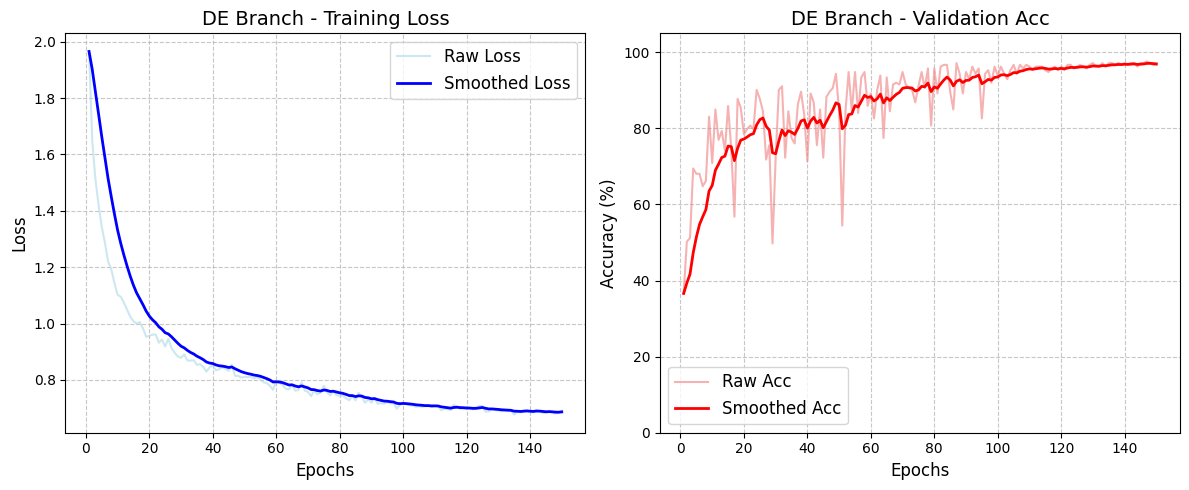

In [32]:
# 建议跑 120 轮，让模型充分收敛
history_DE_128= train_model(channel_name="DE", num_epochs=150)

正在使用 cuda 训练 FE 支路模型...
训练集样本数: 1481, 验证集样本数: 212
Epoch [001/150], Loss: 2.0872, Val Acc: 43.40%, LR(Morlet): 0.000100, LR(Base): 0.000300
Epoch [002/150], Loss: 1.8234, Val Acc: 51.89%, LR(Morlet): 0.000100, LR(Base): 0.000300
Epoch [003/150], Loss: 1.6320, Val Acc: 55.66%, LR(Morlet): 0.000100, LR(Base): 0.000300
Epoch [004/150], Loss: 1.5149, Val Acc: 71.70%, LR(Morlet): 0.000100, LR(Base): 0.000300
Epoch [005/150], Loss: 1.4055, Val Acc: 65.09%, LR(Morlet): 0.000100, LR(Base): 0.000299
Epoch [006/150], Loss: 1.3106, Val Acc: 79.25%, LR(Morlet): 0.000100, LR(Base): 0.000299
Epoch [007/150], Loss: 1.2464, Val Acc: 74.53%, LR(Morlet): 0.000100, LR(Base): 0.000299
Epoch [008/150], Loss: 1.1841, Val Acc: 59.43%, LR(Morlet): 0.000099, LR(Base): 0.000298
Epoch [009/150], Loss: 1.1427, Val Acc: 82.55%, LR(Morlet): 0.000099, LR(Base): 0.000298
Epoch [010/150], Loss: 1.0816, Val Acc: 72.17%, LR(Morlet): 0.000099, LR(Base): 0.000297
Epoch [011/150], Loss: 1.0671, Val Acc: 73.58%, LR(Morlet): 

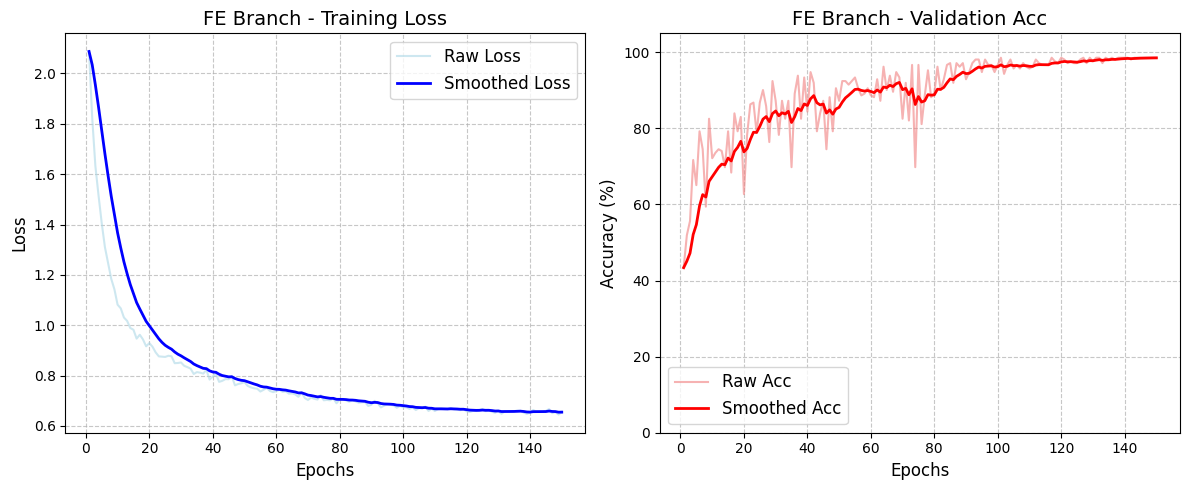

In [33]:
# 建议跑 120 轮，让模型充分收敛
history_FE_128= train_model(channel_name="FE", num_epochs=150)